
# Análisis de espectros estelares
A lo largo de este notebook se van a implementar los códigos básicos de airaf en python. Esto con el objetivo de hacer más llevadero el análisis de las imágenes y los datos, además, para usar una herramienta más actualizada, poderosa y ampliamente utilizada.

In [ ]:
!pip install --upgrade astropy



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 19.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.5 MB/s eta 0:00:00
  Attempting uninstall: astropy
    Found existing installation: astropy 5.3.4
    Uninstalling astropy-5.3.4:
      Successfully uninstalled astropy-5.3.4


In [ ]:
!pip install ccdproc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.6/355.6 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 29.2 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5034 sha256=0c67cd8dc01f3cbb4165b18ed37233dab8aa566612e357e15afa6402b83ae5fe
  Stored in directory: /root/.cache/pip/wheels/7f/4e/be/1171b40f43b918087657ec57cf3b81fa1a2e027d8755baa184
Successfully built asciitree


In [ ]:
!pip install convenience_functions

ERROR: Could not find a version that satisfies the requirement convenience_functions (from versions: none)
ERROR: No matching distribution found for convenience_functions


In [ ]:
#Librerias y paquetes
#astronomy
from glob import glob
from astropy.io import fits
import astropy

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import pandas as pd

# statistics
from astropy.stats import biweight_location, biweight_scale, sigma_clipped_stats
from scipy.stats import median_abs_deviation

#data reading
import imghdr
from PIL import Image
import io

from pathlib import Path
import os
from astropy.nddata import CCDData
from astropy.stats import mad_std
#
from astropy import units as u
from pathlib import Path
from astropy.wcs import WCS

from scipy.stats import lognorm
from matplotlib.colors import LogNorm

from astropy.modeling import models, fitting
from scipy.signal import savgol_filter

from scipy.signal import argrelextrema

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Entendiendo nuestros datos

In [ ]:
#determinar que tipo de información contiene cada imagen

files = glob("/content/drive/MyDrive/Proyecto Computacional/data/*.fits")
files

NameError: name 'glob' is not defined

In [ ]:
(files[0][51:])

'sp0001.fits'

In [ ]:


names=[]

for i in files:
  hdul = fits.open(i)
  data = hdul[0].data
  h1 = hdul[0].header
  names.append(h1.get('OBJECT', 'Unknown'))

In [ ]:
#Diccionario con las llaves de cada imagen y su tipo

image_type= {}
for i in range(len(names)):
  image_type[files[i][51:]] = names[i]
image_type

{'sp0001.fits': 'biases 1st afternoon',
 'sp0002.fits': 'biases 1st afternoon',
 'sp0003.fits': 'biases 1st afternoon',
 'sp0004.fits': 'biases 1st afternoon',
 'sp0005.fits': 'biases 1st afternoon',
 'sp0006.fits': 'biases 1st afternoon',
 'sp0007.fits': 'biases 1st afternoon',
 'sp0008.fits': 'biases 1st afternoon',
 'sp0009.fits': 'biases 1st afternoon',
 'sp0010.fits': 'biases 1st afternoon',
 'sp0011.fits': 'twilight sky',
 'sp0012.fits': 'more twilight sky',
 'sp0013.fits': 'more twilight sky',
 'sp0014.fits': 'flats-6707',
 'sp0015.fits': 'flats-6707',
 'sp0016.fits': 'flats-6707',
 'sp0017.fits': 'flats-6707',
 'sp0018.fits': 'comp 6707 start of night',
 'sp0020.fits': 'DHCep 6707',
 'sp0021.fits': 'DHCep 6707',
 'sp0022.fits': 'DHCep 6707',
 'sp0023.fits': 'AHCep 6707',
 'sp0024.fits': 'AHCep 6707',
 'sp0025.fits': 'AHCep 6707',
 'sp0027.fits': 'comp 6707',
 'bias_master.fits': 'Unknown',
 'sky_flats_master.fits': 'Unknown',
 'flats_master.fits': 'Unknown'}

In [ ]:

types=[]
for i in files:
  hdul = fits.open(i)
  data = hdul[0].data
  h1 = hdul[0].header
  types.append(h1.get('IMAGETYP', 'Unknown'))
types

['zero',
 'zero',
 'zero',
 'zero',
 'zero',
 'zero',
 'zero',
 'zero',
 'zero',
 'zero',
 'object',
 'object',
 'object',
 'flat',
 'flat',
 'flat',
 'flat',
 'comp',
 'object',
 'object',
 'object',
 'object',
 'object',
 'object',
 'comp',
 'Unknown',
 'Unknown',
 'Unknown']

In [ ]:
img_ty={}
for i in range(len(names)):
  img_ty[files[i][51:]] = types[i]
img_ty


{'sp0001.fits': 'zero',
 'sp0002.fits': 'zero',
 'sp0003.fits': 'zero',
 'sp0004.fits': 'zero',
 'sp0005.fits': 'zero',
 'sp0006.fits': 'zero',
 'sp0007.fits': 'zero',
 'sp0008.fits': 'zero',
 'sp0009.fits': 'zero',
 'sp0010.fits': 'zero',
 'sp0011.fits': 'object',
 'sp0012.fits': 'object',
 'sp0013.fits': 'object',
 'sp0014.fits': 'flat',
 'sp0015.fits': 'flat',
 'sp0016.fits': 'flat',
 'sp0017.fits': 'flat',
 'sp0018.fits': 'comp',
 'sp0020.fits': 'object',
 'sp0021.fits': 'object',
 'sp0022.fits': 'object',
 'sp0023.fits': 'object',
 'sp0024.fits': 'object',
 'sp0025.fits': 'object',
 'sp0027.fits': 'comp',
 'bias_master.fits': 'Unknown',
 'sky_flats_master.fits': 'Unknown',
 'flats_master.fits': 'Unknown'}

# Reducción de imágenes a partir de los bias y flats

Para la calibración de nuestros espectros se deben seguir una serie de pasos especificados en el tutorial de IRAF. El objetivo de esta sección es implementar los algoritmos propios de IRAF en Python para realizar la calibración completa en este lenguaje de programación. Los pasos a seguir según el tutorial guía son:

**Paso 1: Combinar los 10 BIAS en un solo frame**

La combinación se hace con el propósito de obtener un bias master que tenga menos ruido de lectura que los bias individuales. Puede verse más a fondo el proceso realizado acá:
  - https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/02-04-Combine-bias-images-to-make-master.html

Para esto se usa la función ZEROCOMBINE de IRAF, que recibe los siguientes parámetros:

cl> lpar zerocombine
        
        
        
        
        input =                 List of zero level images to combine
      (output = "Zero")         Output zero level name
     (combine = "average")      Type of combine operation
      (reject = "minmax")       Type of rejection
     (ccdtype = "zero")         CCD image type to combine
     (process = no)             Process images before combining?
      (delete = no)             Delete input images after combining?
     (clobber = no)             Clobber existing output image?
       (scale = "none")         Image scaling
     (statsec = "")             Image section for computing statistics
        (nlow = 0)              minmax: Number of low pixels to reject
       (nhigh = 1)              minmax: Number of high pixels to reject
       (nkeep = 1)              Minimum to keep (pos) or maximum to reject (neg
       (mclip = yes)            Use median in sigma clipping algorithms?
      (lsigma = 3.)             Lower sigma clipping factor
      (hsigma = 3.)             Upper sigma clipping factor
     (rdnoise = "0.")           ccdclip: CCD readout noise (electrons)
        (gain = "1.")           ccdclip: CCD gain (electrons/DN)
      (snoise = "0.")           ccdclip: Sensitivity noise (fraction)
       (pclip = -0.5)           pclip: Percentile clipping parameter
       (blank = 0.)             Value if there are no pixels
        (mode = "ql")      

En esta sección se verá como se implementa la lógica de esta función en Python para obtener la imagen BIAS a usar



In [ ]:
# Sacamos los 10 bias aparte

bias_paths=[]
for i in range(len(types)):
  if types[i] == 'zero':
    bias_paths.append(files[i])
bias_paths
#En este caso bias son las rutas a las imágenes bias de calibración, ahora se deben extraer sus datos para trabajar

['/content/drive/MyDrive/Proyecto Computacional/data/sp0001.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0002.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0003.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0004.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0005.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0006.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0007.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0008.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0009.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0010.fits']

In [ ]:
import ccdproc

In [ ]:
# Matriz con los datos para las imágenes bias
bias_ccd_list=[]
for bias_path in bias_paths:
    hdul = fits.open(bias_path)
    bias_data = hdul[0].data
    bias_unit = u.adu
    # Crear un objeto CCDData para la imagen bias
    bias_ccd = ccdproc.CCDData(data=bias_data, unit=bias_unit)
    bias_ccd_list.append(bias_ccd)

In [ ]:
# Este bloque de código es el análogo al zeroadjust de IRAF, la única diferencia es que no se omiten los valore mas altos de píxel

combined_bias = ccdproc.combine(bias_ccd_list, method='average',
                                sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3,
                                sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std, mem_limit=350e6)

combined_bias.meta['combined'] = True

# rutas
calibrated_path = Path('/content/drive/MyDrive/Proyecto Computacional/data')
combined_bias.write(calibrated_path / 'bias_master.fits', overwrite=True)


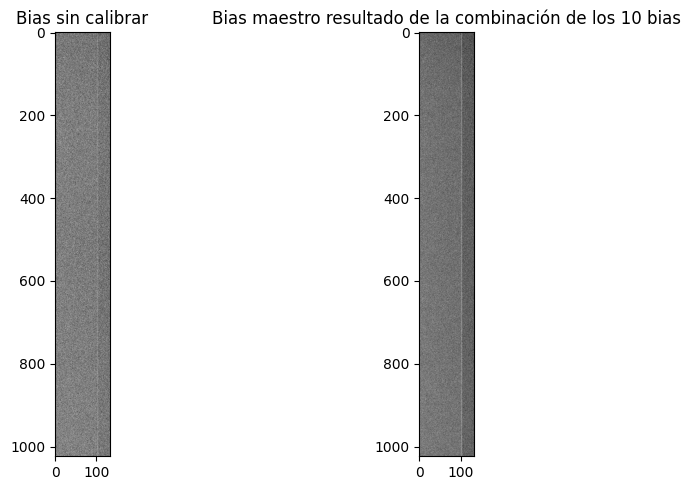

In [ ]:
#mostramos el bias calibrado

bias_=  '/content/drive/MyDrive/Proyecto Computacional/data/sp0001.fits'
hdul = fits.open(bias_)
data1 = hdul[0].data
h0 = hdul[0].header

bias_calibrado=  '/content/drive/MyDrive/Proyecto Computacional/data/bias_master.fits'
hdul = fits.open(bias_calibrado)
data = hdul[0].data
h1 = hdul[0].header

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(data1, cmap='gray',norm=LogNorm())
ax1.set_title('Bias sin calibrar')

ax2.imshow(data, cmap='gray',norm=LogNorm())
ax2.set_title('Bias maestro resultado de la combinación de los 10 bias')


plt.tight_layout()
plt.show()

**Paso 2: Determinar el overscan y los parametros de recorte para los datos**

Para saber esto es necesario ver una imagen flats

101


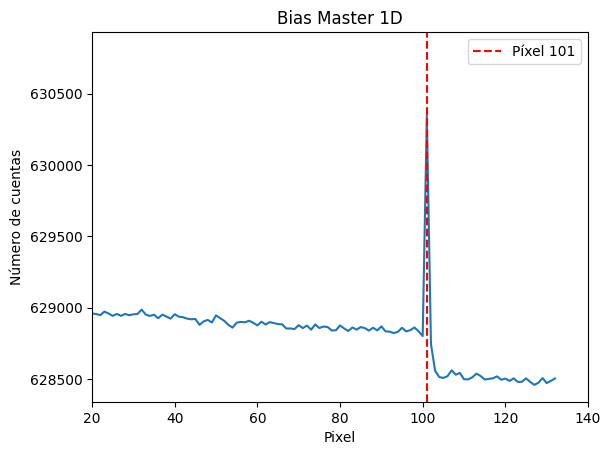

In [ ]:
#Overscan
hdul = fits.open(bias_calibrado)
data_bias_master = hdul[0].data


bias_master_1D = np.sum(data_bias_master, axis=0)
maximo= np.max(bias_master_1D[40:120])
bias_master_1D= bias_master_1D.tolist()
pos_max= bias_master_1D.index(maximo)
print(pos_max)
# Mostrar una gráfica del espectro 1D
plt.plot(bias_master_1D)
plt.xlabel('Pixel')
plt.ylabel('Número de cuentas')

plt.axvline(x=pos_max, color='red', linestyle='--', label='Píxel 101')
plt.xlim(20,140)
plt.title('Bias Master 1D')
plt.legend()
plt.show()


Cómo se observa en el gráfico anterior aproximadamente a partir del píxel 101 empieza a decaer el número de cuentas por píxel, así que a partir de este punto empieza la zona de overscan. Lo siguiente será calcular el promedio de cuentas por píxel de la zona de overscan y restarle este número a todos los píxeles de las imágenes CCD.

In [ ]:
#Promedio de cuentas para la región de overscan

over_region= len(data[0])-pos_max #Región de overscan

sumatoria= sum(bias_master_1D[101:133])
promedio= sumatoria/over_region
promedio

628569.7388516866

1024


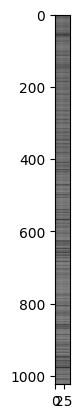

In [ ]:
flat= '/content/drive/MyDrive/Proyecto Computacional/data/sp0013.fits'
hdul = fits.open(flat)
data = hdul[0].data
h0 = hdul[0].header
print(len(data))

espec = np.sum(data.T, axis=0)
espec= espec.tolist()

fig9 = plt.figure()
plt.imshow(data, cmap='gray',norm=LogNorm())
plt.grid(False)

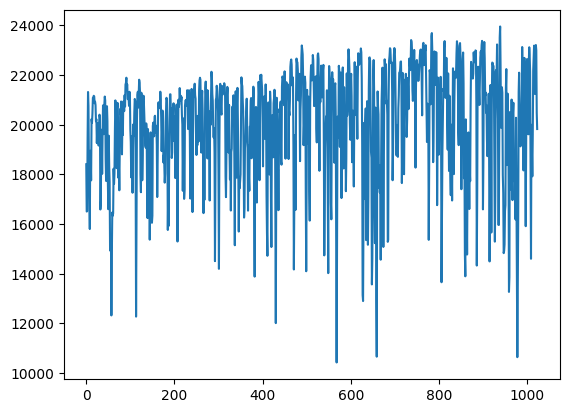

In [ ]:
plt.plot(espec)

In [ ]:
# A partir de lo nterior se establecieron los siguientes parámetros de recorte: [34,74] para las columnas y [1:1022] para las columnas

In [ ]:
# Recorte para las imágenes de los espectros de calibración y análisis:
#Las imágenes ya están recortadas en este caso, entonces esta parte es innecesaria, pero lo que se hacía era iterar sobre las imágenes y recortarlas usando operaciones de listas y matrices

for i in files:
  if i != '/content/drive/MyDrive/Proyecto Computacional/data/bias_master.fits':
    hdul = fits.open(i)
    data = hdul[0].data
    print(i)
    print(len(data))
    print(len(data[0]))
#Vemos que las 10 primeras imágenes no están cortadas, pero estas son los bias


/content/drive/MyDrive/Proyecto Computacional/data/sp0001.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0002.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0003.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0004.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0005.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0006.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0007.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0008.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0009.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0010.fits
1024
133
/content/drive/MyDrive/Proyecto Computacional/data/sp0011.fits
1024
41
/content/drive/MyDrive/Proyecto Computacional/data/sp0012.fits
1024
41
/content/drive/MyDrive/Proyecto Computacional/data/sp0013.fits
1024
41
/content/drive/MyDrive/Proyecto Computacional/data/sp0014.fits
1024

In [ ]:
# Quitar el overscan a cada píxel de las imágenes

In [ ]:

for i in files:
  if i != '/content/drive/MyDrive/Proyecto Computacional/data/bias_master.fits':
    hdul = fits.open(i)
    data = hdul[0].data
    spec1D= np.sum(data, axis=0) #Pasamos del espectro 2D a 1D
    print((spec1D)-promedio)
 #Al parecer las imágenes ya estaban procesadas por overscan tmb ya que me dan resultados negativos, hay que comprobar



[ 1.91126115e+03  3.96261148e+02  2.54261148e+02  2.09261148e+02
  1.68261148e+02  1.43261148e+02  1.31261148e+02  1.94261148e+02
  1.13261148e+02  6.02611483e+01  1.29261148e+02  1.55261148e+02
  2.14261148e+02  1.74261148e+02  1.16261148e+02  1.22261148e+02
  9.12611483e+01  9.62611483e+01  4.32611483e+01  1.35261148e+02
  6.12611483e+01  1.18261148e+02  3.42611483e+01  1.02261148e+02
  1.34261148e+02  6.92611483e+01  3.32611483e+01  8.92611483e+01
  1.36261148e+02  1.65261148e+02  1.06261148e+02  1.14261148e+02
  1.66261148e+02  9.52611483e+01  3.62611483e+01  1.11261148e+02
  6.62611483e+01  3.82611483e+01  4.72611483e+01  1.36261148e+02
  4.42611483e+01  6.42611483e+01  8.12611483e+01  7.92611483e+01
  7.72611483e+01  8.22611483e+01 -1.07388517e+01  6.26114831e+00
  2.82611483e+01 -1.37388517e+01  9.02611483e+01  4.12611483e+01
 -1.17388517e+01  7.26114831e+00 -1.97388517e+01 -1.67388517e+01
 -4.27388517e+01  9.26114831e+00 -3.73885169e+00  2.02611483e+01
  4.62611483e+01 -2.73885

In [ ]:
name= '/content/drive/MyDrive/Proyecto Computacional/data/sp0001.fits'
first_bias = CCDData.read(name, format='fits', unit='adu')

Changed DATE-OBS from '24/01/92' to '1992-01-24''. [astropy.wcs.wcs]
Changed DATE-OBS from '24/01/92' to '1992-01-24''.


In [ ]:
import ccdproc as ccdp

In [ ]:
#bias_overscan_subtracted = ccdp.subtract_overscan(data, overscan=first_bias[105:130,1:1022], median=True)

#Este bloque le intentaba quitar la región de overscan a los bias

In [ ]:
#trimmed_bias = ccdp.trim_image(bias_overscan_subtracted[34:74,1:1022])

#continuación del código de la celda anterior

In [ ]:
#Los anteriores son códigos de astropy, este es un código implementado teniendo como base la tarea 'ccdproc' de IRAF:
"""
import numpy as np
from astropy.io import fits
from ccdproc import CCDData, subtract_overscan, trim_image, subtract_bias, flat_correct

def ccdproc(images, ccdtype="", max_cache=0, noproc=False, fixpix=False, overscan=True, trim=True,
            zerocor=True, darkcor=False, flatcor=False, illumcor=False, fringecor=False,
            readcor=False, scancor=False, readaxis="line", fixfile="", biassec="[105:130,1:1022]",
            trimsec="[34:74,1:1022]", zero="Zero", dark="", flat="", illum="", fringe="",
            minreplace=1.0, scantype="shortscan", nscan=1, interactive=True, function="chebyshev",
            order=1, sample="*", naverage=1, niterate=1, low_reject=3.0, high_reject=3.0,
            grow=0.0, mode="ql"):

    processed_images = []

    for image in images:
        ccd_data = CCDData.read(image, format='fits', unit='adu')


        if not noproc:
            if fixpix:
                # se implementa la lógica si es 'True' pero no es el caso
                pass

            if overscan:
                ccd_data = subtract_overscan(ccd_data, overscan_axis=1, fits_section=biassec)

            if trim:
                # Trim the image
                ccd_data = trim_image(ccd_data, fits_section=trimsec)

            if zerocor:
                # Apply zero level correction
                zero_data = CCDData.read(zero)
                ccd_data = subtract_bias(ccd_data, zero_data)

            if darkcor:
                # Apply dark count correction
                dark_data = CCDData.read(dark)
                # Implement the logic here
                pass

            if flatcor:
                # Apply flat field correction
                flat_data = CCDData.read(flat)
                pass

            if illumcor:
                illum_data = CCDData.read(illum)
                pass

            if fringecor:
                fringe_data = CCDData.read(fringe)
                pass

            if readcor:
                pass

            if scancor:
                pass

    return processed_images
img1= '/content/drive/MyDrive/Proyecto Computacional/data/sp0011.fits'
img2= '/content/drive/MyDrive/Proyecto Computacional/data/sp0014.fits'
images_to_process = [img1,img2]
processed_images = ccdproc(images=images_to_process, noproc=False, overscan=True, trim=True, zerocor=True)"""

#Este código fue un intento propio de replicar el algoritmo de IRAF para recortar las imágnes


'\nimport numpy as np\nfrom astropy.io import fits\nfrom ccdproc import CCDData, subtract_overscan, trim_image, subtract_bias, flat_correct\n\ndef ccdproc(images, ccdtype="", max_cache=0, noproc=False, fixpix=False, overscan=True, trim=True,\n            zerocor=True, darkcor=False, flatcor=False, illumcor=False, fringecor=False,\n            readcor=False, scancor=False, readaxis="line", fixfile="", biassec="[105:130,1:1022]",\n            trimsec="[34:74,1:1022]", zero="Zero", dark="", flat="", illum="", fringe="",\n            minreplace=1.0, scantype="shortscan", nscan=1, interactive=True, function="chebyshev",\n            order=1, sample="*", naverage=1, niterate=1, low_reject=3.0, high_reject=3.0,\n            grow=0.0, mode="ql"):\n\n    processed_images = []\n\n    for image in images:\n        ccd_data = CCDData.read(image, format=\'fits\', unit=\'adu\')\n\n\n        if not noproc:\n            if fixpix:\n                # se implementa la lógica si es \'True\' pero no es el

<Figure size 640x480 with 0 Axes>

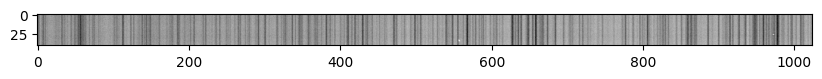

In [ ]:
espectro=  '/content/drive/MyDrive/Proyecto Computacional/data/sp0011.fits'
hdul = fits.open(espectro)
data = hdul[0].data
h0 = hdul[0].header

fig9 = plt.figure()
plt.figure(figsize=(10,5))
plt.imshow(data.T, cmap='gray',norm=LogNorm())
plt.grid(False)

**Parte 3 Combinación de los flats:**

Luego de haber procesado las imágenes se deben combinar los flats para obtener un flat maestro, con menos ruido que los flats originales. Como la parte anterior no me funcionó voy a proceder a fusionarlos san¿biendo que eso le agrega ruido a mis datos, sin embargo, quiero avanzar y ya luego arreglo el problema

In [ ]:
flats_paths=[]
for i in range(len(types)):
  if types[i] == 'flat':
    flats_paths.append(files[i])

In [ ]:
flats_paths

['/content/drive/MyDrive/Proyecto Computacional/data/sp0014.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0015.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0016.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0017.fits']

In [ ]:
import ccdproc
from ccdproc import CCDData

In [ ]:

flats_ccd_list=[]
for flat_path in flats_paths:
    hdul = fits.open(flat_path)
    flats_data = hdul[0].data
    flat_unit = u.adu

    flats_ccd = ccdproc.CCDData(data=flats_data, unit=flat_unit)
    flats_ccd_list.append(flats_ccd)

In [ ]:

combined_flats = ccdproc.combine(flats_ccd_list, method='average',
                                sigma_clip=True, sigma_clip_low_thresh=3, sigma_clip_high_thresh=3,
                                sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std, mem_limit=350e6)

combined_flats.meta['combined'] = True

# rutas
calibrated_path = Path('/content/drive/MyDrive/Proyecto Computacional/data')
combined_flats.write(calibrated_path / 'flats_master.fits', overwrite=True)

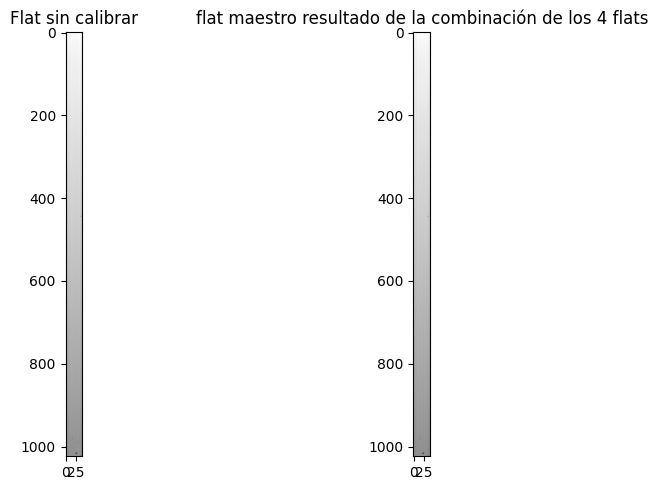

In [ ]:
flat=  '/content/drive/MyDrive/Proyecto Computacional/data/sp0014.fits'
hdul = fits.open(flat)
data1 = hdul[0].data
h0 = hdul[0].header

flat_calibrado=  '/content/drive/MyDrive/Proyecto Computacional/data/flats_master.fits'
hdul = fits.open(flat_calibrado)
data = hdul[0].data
h1 = hdul[0].header

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(data1, cmap='gray',norm=LogNorm())
ax1.set_title('Flat sin calibrar')

ax2.imshow(data, cmap='gray',norm=LogNorm())
ax2.set_title('flat maestro resultado de la combinación de los 4 flats')


plt.tight_layout()
plt.show()

**Parte 4 procesar los sky flats, objetos y comps (Eliminar el overscan, recorte y zero correction):**

En esta parte se van a aplicar las correciones bias, flats y overscan a las imágenes a analizar.


Normalized FlatField:

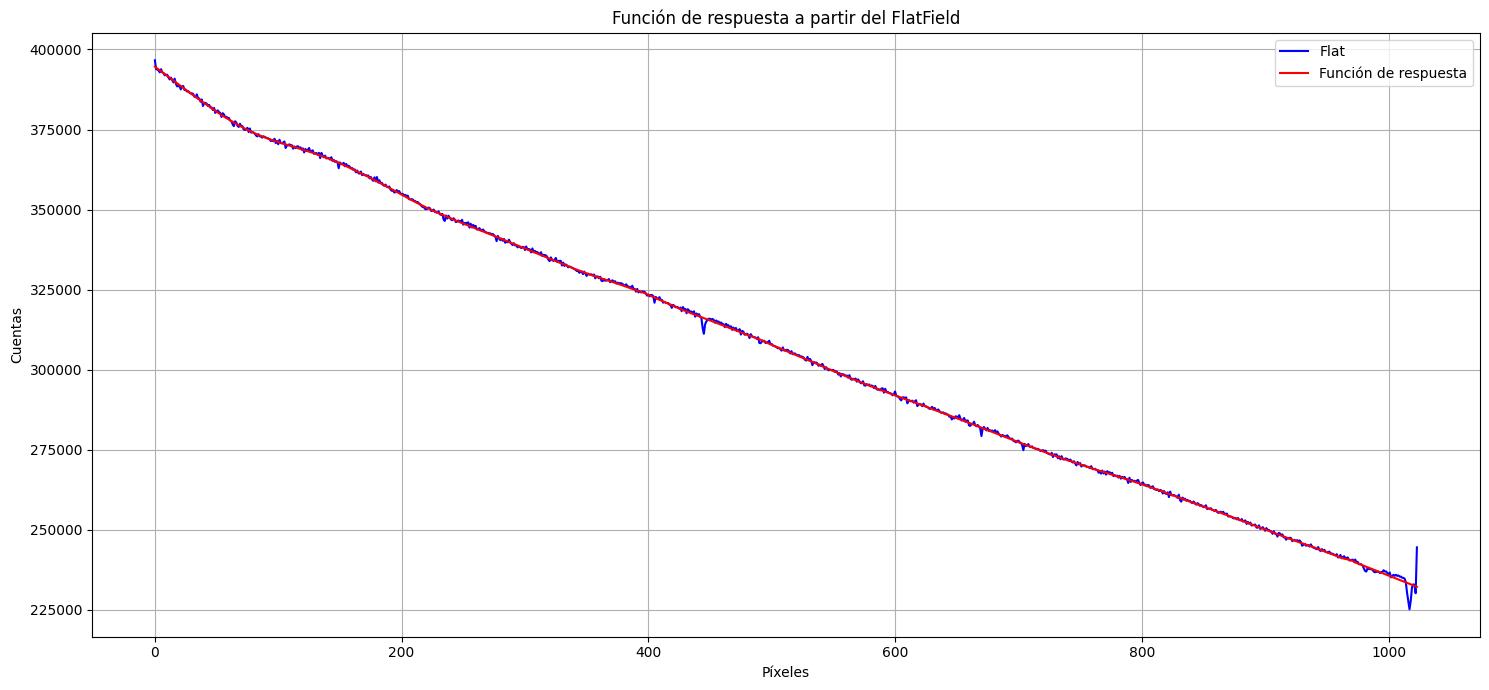

In [ ]:
#Se usa el flat master:

hdul = fits.open(flat_calibrado)
data = hdul[0].data

flat_calibrado_1D= np.sum(data.T, axis=0)
flat_calibrado_1D= flat_calibrado_1D.tolist()

#Linea de ajuste:
continuo_fit = savgol_filter(flat_calibrado_1D, 100, 3)

#Cálculo de la función de respuesta:
#Se divide entre cada columna del flat de entrada

funcion_respuesta= continuo_fit/flat_calibrado_1D

plt.figure(figsize=(15, 7))
plt.plot(flat_calibrado_1D, label='Flat', color='blue')
plt.plot(continuo_fit, label='Función de respuesta', color='red')
plt.xlabel('Píxeles')
plt.ylabel('Cuentas')
plt.title('Función de respuesta a partir del FlatField')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



Inspección y corrección de los SkyFlats

In [ ]:

sky_flats_paths=[]
for i in range(len(names)):
  if names[i] == 'more twilight sky' or names[i] == 'twilight sky':
    sky_flats_paths.append(files[i])

sky_flats_paths

['/content/drive/MyDrive/Proyecto Computacional/data/sp0011.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0012.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0013.fits']

In [ ]:
# Combinación de los SkyFlats


sky_flats_ccd_list=[]
for flat_path in sky_flats_paths:
    hdul = fits.open(flat_path)
    flats_data = hdul[0].data
    flat_unit = u.adu

    flats_ccd = ccdproc.CCDData(data=flats_data, unit=flat_unit)
    sky_flats_ccd_list.append(flats_ccd)


combined_sky_flats = ccdproc.combine(sky_flats_ccd_list, method='average',
                                sigma_clip=False)

combined_sky_flats.meta['combined'] = True

# rutas
calibrated_path = Path('/content/drive/MyDrive/Proyecto Computacional/data')
combined_sky_flats.write(calibrated_path / 'sky_flats_master.fits', overwrite=True)

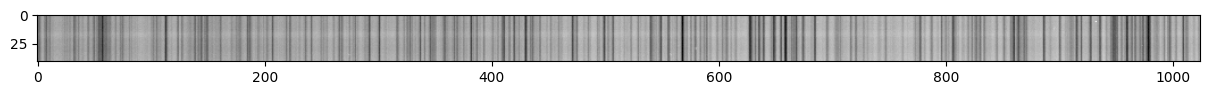

In [ ]:

flat_calibrado=  '/content/drive/MyDrive/Proyecto Computacional/data/sky_flats_master.fits'
hdul = fits.open(flat_calibrado)
data = hdul[0].data
h1 = hdul[0].header

fig9 = plt.figure(figsize=(15,10))
plt.imshow(data.T, cmap='gray',norm=LogNorm())
plt.grid(False)

# **Calibración en Longitud de Onda**

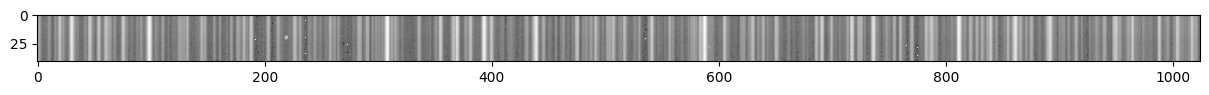

In [ ]:
# Usamos el espectro de la lámpara de calibración: sp0018.fits 'comp 6707 start of night',

lampara=  '/content/drive/MyDrive/Proyecto Computacional/data/sp0027.fits'
hdul = fits.open(lampara)
data = hdul[0].data
h1 = hdul[0].header

fig9 = plt.figure(figsize=(15,10))
plt.imshow(data.T, cmap='gray',norm=LogNorm())
plt.grid(False)

In [ ]:
h1

SIMPLE  =                    T / Fits standard                                  
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                   41 / Axis length                                    
NAXIS2  =                 1024 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2014-09-09T20:15:05' / Date FITS file was generated                  
IRAF-TLM= '2014-09-09T20:15:05' / Time of last modification                     
OBJECT  = 'comp 6707'          / Name of the object observed                    
IRAF-MAX=           2.848000E4  /  DATA MAX                                     
IRAF-MIN=           6.080000E2  /  DATA MIN                                     
OBSERVAT= 'KPNO             

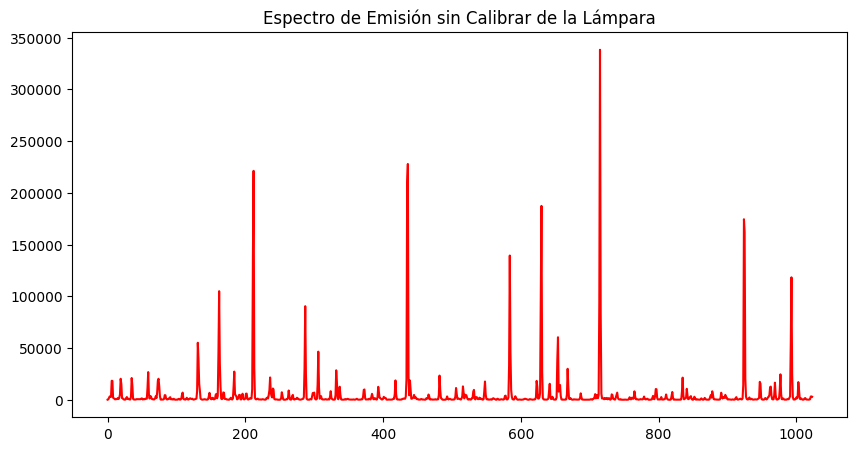

In [ ]:
# En 1D:

lampara1D= np.sum(data, axis=1)


plt.figure(figsize=(10, 5))
plt.title("Espectro de Emisión sin Calibrar de la Lámpara")
plt.plot(np.flip(lampara1D), label='Lámpara de Calibración', color='red')



**Espectro de Calibración: **

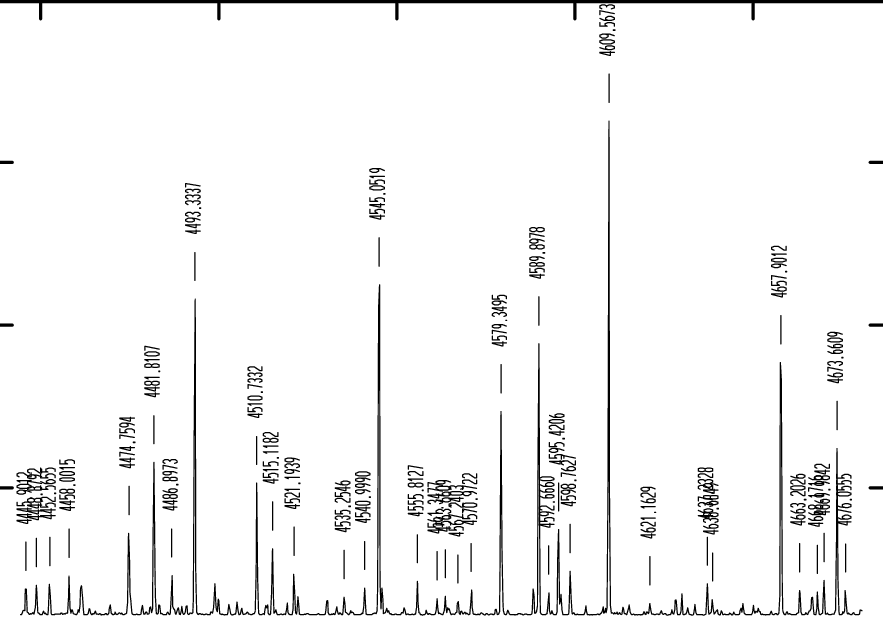

# **IMPORTANTE: Se debe hacer una reflexión respecto al eje x de los datos del espectro para que coincida con el espectro de calibración. Muy seguramente esto se deba aplicar al resto de las imágenes a analizar**

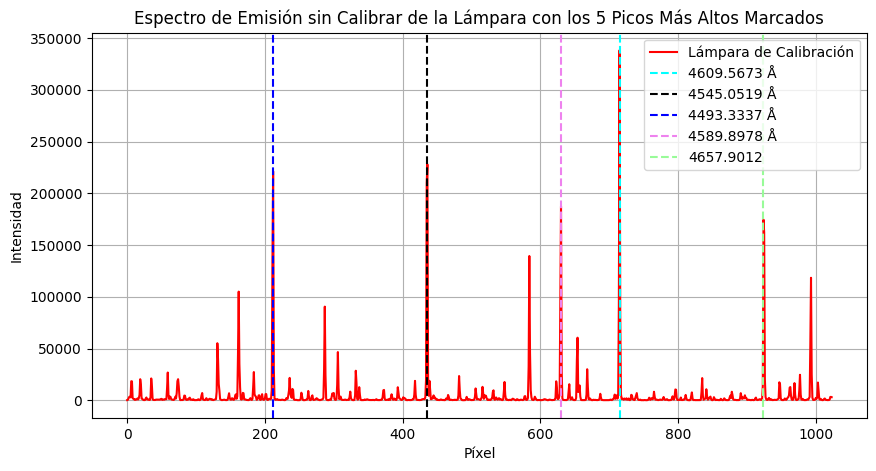

[212, 436, 630, 715, 924]


In [ ]:

lampara1D= np.sum(data, axis=1)
indices_picos = argrelmax(lampara1D, order=5)[0]
picos_altos = lampara1D[indices_picos]
sorted_indices = indices_picos[np.argsort(-picos_altos)]
posiciones_picos = sorted_indices[:5]  #5 primeros picos más altos

# Invertir  x
lampara1D_invertida = np.flip(lampara1D)

colores = ['aqua', 'black', 'blue', 'violet', 'palegreen']
labels = ['4609.5673 Å', '4545.0519 Å', '4493.3337 Å', '4589.8978 Å', '4657.9012']
plt.figure(figsize=(10, 5))
plt.title("Espectro de Emisión sin Calibrar de la Lámpara con los 5 Picos Más Altos Marcados")
plt.plot(lampara1D_invertida, label='Lámpara de Calibración', color='red')
plt.xlabel('Píxel')
plt.ylabel('Intensidad')
plt.grid(True)

pixeles=[]
for i, (pos, color, label) in enumerate(zip(posiciones_picos, colores, labels)):
    x= (len(lampara1D_invertida) - pos - 1)
    pixeles.append(x) #valores de pixeles para cada pico
    plt.axvline(x, color=color, linestyle='--', label=label)  # Restamos pos y restamos 1 por la inversión


plt.legend()
plt.show()

pixeles= sorted(pixeles)
print(pixeles)


In [ ]:
#Relación pixel/longitud de onda

wavelenghts= [4493.3337, 4545.0519, 4589.8978, 4609.5673, 4657.9012]

ratio=[]

for i in range(len(wavelenghts)):
  j = i+1
  if j <= 4:
    r= (wavelenghts[j]-wavelenghts[i])/(pixeles[j]-pixeles[i])
    ratio.append(r)

    ratio_sum = sum(ratio)
    angs_pixel = ratio_sum / len(ratio)

print("Factor de calibración (Å/píxel):", angs_pixel)


Factor de calibración (Å/píxel): 0.23117945404926016


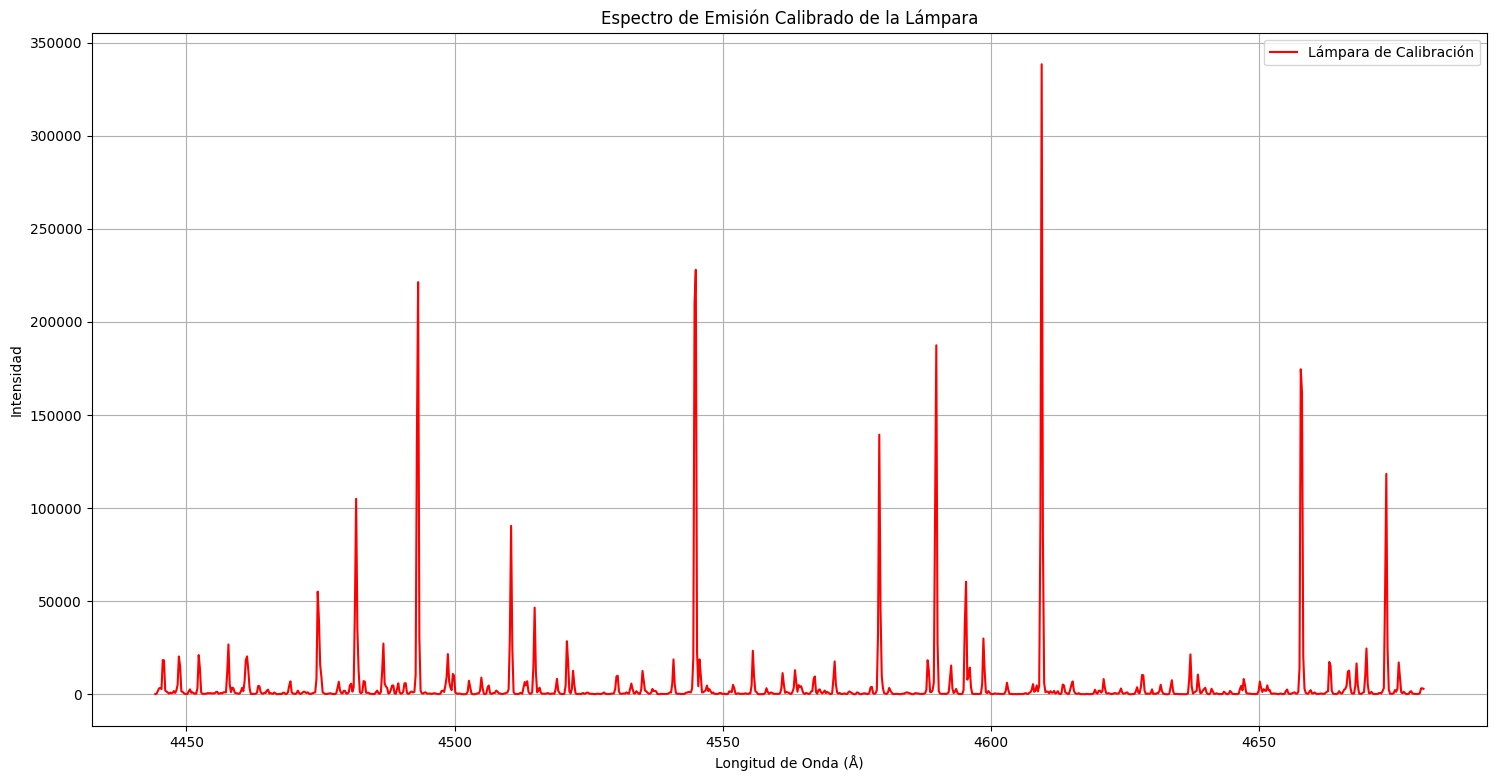

4516.004471847172

In [ ]:


factor_calibracion =angs_pixel
lampara1D = np.flip(np.sum(data, axis=1))

#factor de calibración a cada posición en píxeles
posiciones_calibradas = np.flip(np.arange(len(lampara1D)) * factor_calibracion + 4444.2012)


plt.figure(figsize=(18, 9))
plt.title("Espectro de Emisión Calibrado de la Lámpara")
plt.plot(posiciones_calibradas, np.flip(lampara1D), label='Lámpara de Calibración', color='red')
plt.xlabel('Longitud de Onda (Å)')
plt.ylabel('Intensidad')
plt.grid(True)
plt.legend()
plt.show()
posiciones_picos[0]

In [ ]:
#Calibración de las demás imágenes de interés


#Imágenes a calibrar:
calibrar=[]

for i in range(len(names)):
  if names[i] == 'DHCep 6707' or names[i] == 'AHCep 6707':
    calibrar.append(files[i])
calibrar

['/content/drive/MyDrive/Proyecto Computacional/data/sp0020.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0021.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0022.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0023.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0024.fits',
 '/content/drive/MyDrive/Proyecto Computacional/data/sp0025.fits']

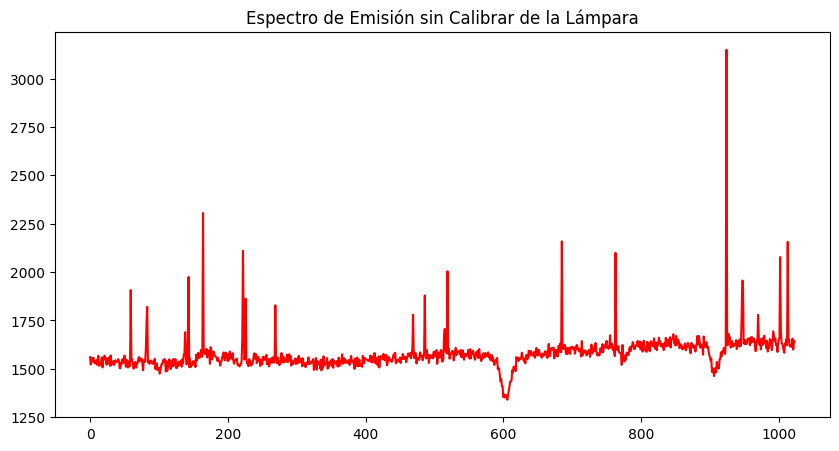

In [ ]:
lampara=  '/content/drive/MyDrive/Proyecto Computacional/data/sp0020.fits'
hdul = fits.open(lampara)
data = hdul[0].data
h1 = hdul[0].header


lampara1D= np.sum(data, axis=1)

plt.figure(figsize=(10, 5))
plt.title("Espectro de Emisión sin Calibrar de la Lámpara")
plt.plot((lampara1D), label='Lámpara de Calibración', color='red')

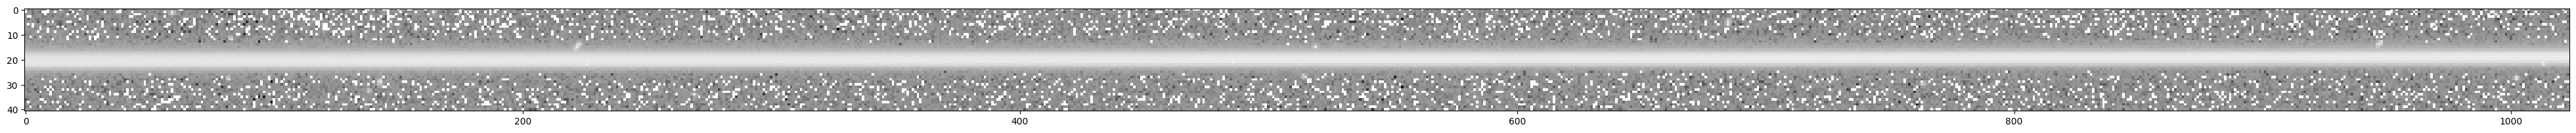

In [ ]:

fig9 = plt.figure(figsize=(,15))
plt.imshow(data.T, cmap='gray',norm=LogNorm())
plt.grid(False)


In [ ]:
# Graficas sin calibrar

spectrum_2d=[]
spectrum_1d=[]
spectrum_calibrated=[]

#Generamos la imagen de los espectros en 2d, en 1d sin calibrar y calibrado
for i in calibrar:
  hdul = fits.open(i)
  data = hdul[0].data
  h1 = hdul[0].header
  spectrum_2d.append(data)

for j in spectrum_2d:
  spec= np.flip(np.sum(j, axis=1))
  spectrum_1d.append(spec)

for k in spectrum_1d:
  calibrated = (np.arange(len(k)) * factor_calibracion + 4444.2012)
  spectrum_calibrated.append(calibrated)

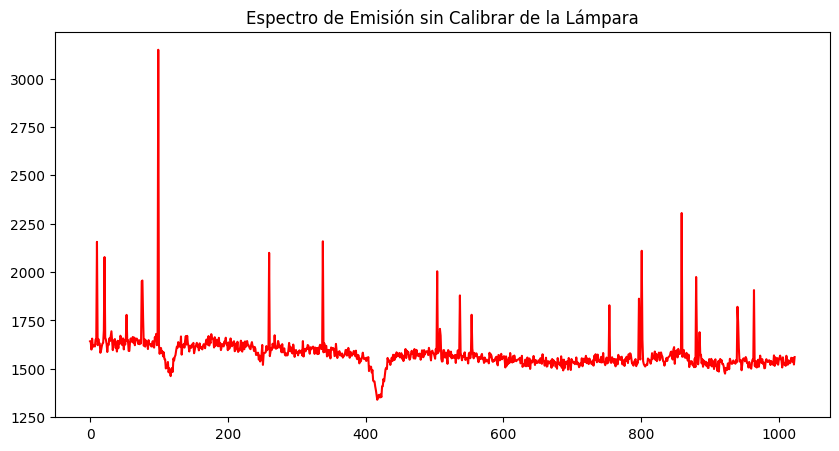

In [ ]:
spectrum_1d

[array([1642.5754, 1637.0944, 1599.7623, ..., 1555.0624, 1522.513 ,
        1560.9535], dtype=float32),
 array([1454.2263, 1478.2594, 1461.2247, ..., 1398.3713, 1366.2185,
        1361.8337], dtype=float32),
 array([1562.3767, 1564.0085, 1559.412 , ..., 1478.1682, 1464.1722,
        1504.9257], dtype=float32),
 array([5593.6226, 5598.997 , 5590.7554, ..., 5076.6855, 5040.918 ,
        5019.1333], dtype=float32),
 array([5154.826 , 5202.9214, 5169.403 , ..., 4752.7827, 4687.4683,
        4668.144 ], dtype=float32),
 array([4481.092 , 4499.361 , 4515.878 , ..., 4094.7512, 4156.7163,
        4122.8477], dtype=float32)]

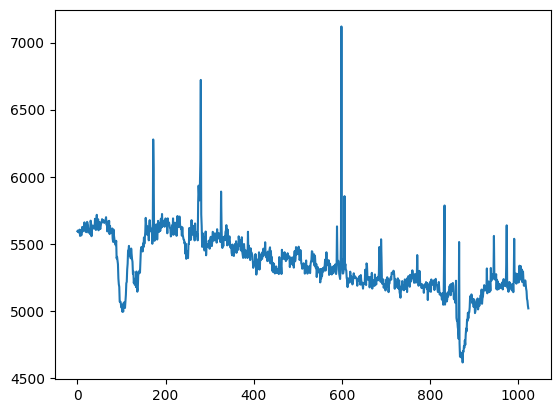

In [ ]:
plt.plot(spectrum_1d[3])

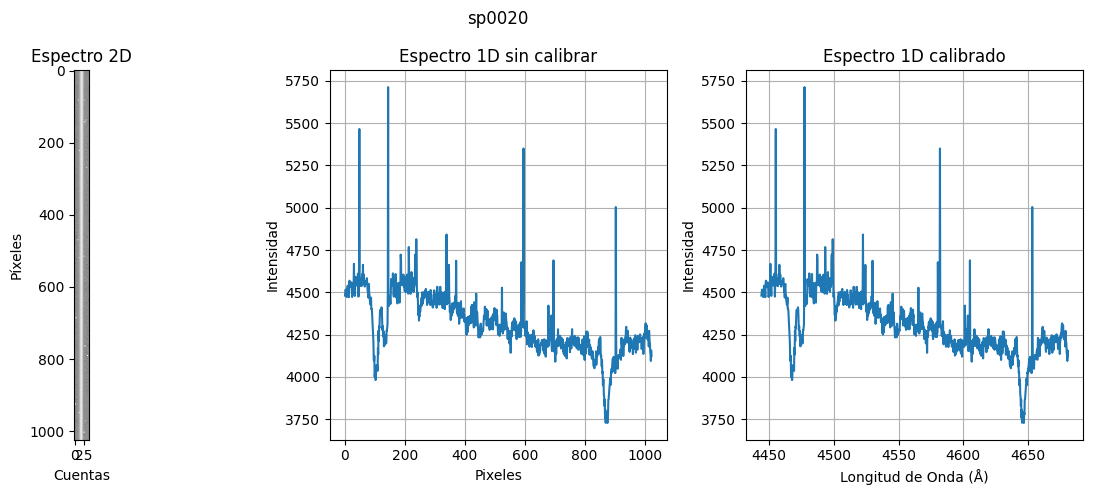

In [ ]:
#sp0020
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axs[0].imshow(spectrum_2d[0], cmap='gray',norm=LogNorm())
axs[0].set_title('Espectro 2D')
axs[0].set_xlabel('Cuentas')
axs[0].set_ylabel('Píxeles')
axs[0].grid(False)

axs[1].plot(spectrum_1d[0])
axs[1].set_title('Espectro 1D sin calibrar')
axs[1].set_xlabel('Pixeles')
axs[1].set_ylabel('Intensidad')
axs[1].grid(True)

axs[2].plot(spectrum_calibrated[0], spectrum_1d[0])
axs[2].set_title('Espectro 1D calibrado')
axs[2].set_xlabel('Longitud de Onda (Å)')
axs[2].set_ylabel('Intensidad')
axs[2].grid(True)

fig.suptitle('sp0020')
plt.tight_layout()

plt.show()


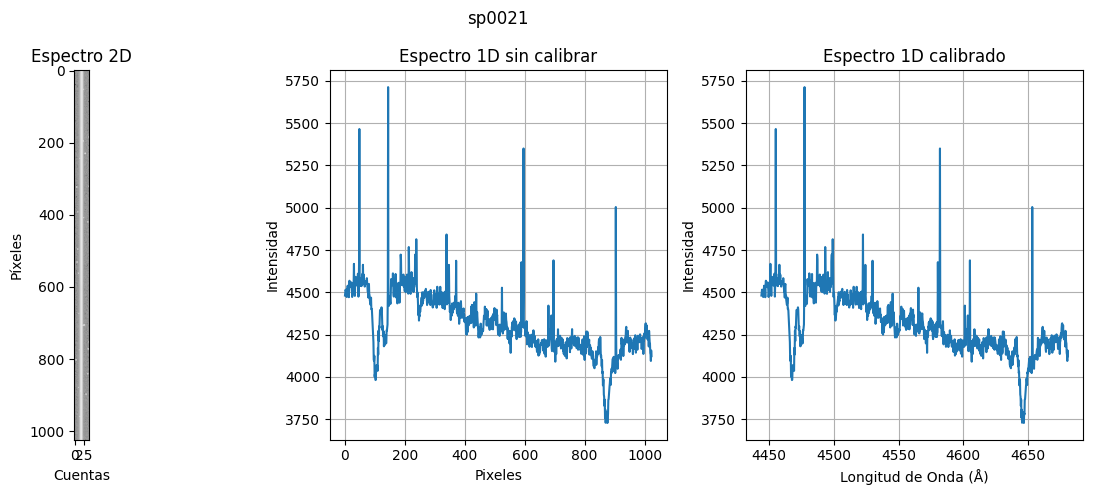

In [ ]:
#sp0021
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axs[0].imshow(spectrum_2d[1], cmap='gray',norm=LogNorm())
axs[0].set_title('Espectro 2D')
axs[0].set_xlabel('Cuentas')
axs[0].set_ylabel('Píxeles')
axs[0].grid(False)

axs[1].plot(spectrum_1d[1])
axs[1].set_title('Espectro 1D sin calibrar')
axs[1].set_xlabel('Pixeles')
axs[1].set_ylabel('Intensidad')
axs[1].grid(True)

axs[2].plot(spectrum_calibrated[1], spectrum_1d[1])
axs[2].set_title('Espectro 1D calibrado')
axs[2].set_xlabel('Longitud de Onda (Å)')
axs[2].set_ylabel('Intensidad')
axs[2].grid(True)

fig.suptitle('sp0021')
plt.tight_layout()

plt.show()


In [ ]:
#sp0020
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axs[0].imshow(spectrum_2d[0], cmap='gray',norm=LogNorm())
axs[0].set_title('Espectro 2D')
axs[0].set_xlabel('Cuentas')
axs[0].set_ylabel('Píxeles')
axs[0].grid(False)

axs[1].plot(spectrum_1d[0])
axs[1].set_title('Espectro 1D sin calibrar')
axs[1].set_xlabel('Pixeles')
axs[1].set_ylabel('Intensidad')
axs[1].grid(True)

axs[2].plot(spectrum_calibrated[0], spectrum_1d[0])
axs[2].set_title('Espectro 1D calibrado')
axs[2].set_xlabel('Longitud de Onda (Å)')
axs[2].set_ylabel('Intensidad')
axs[2].grid(True)

fig.suptitle('sp0020')
plt.tight_layout()

plt.show()


In [ ]:
#sp0020
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axs[0].imshow(spectrum_2d[0], cmap='gray',norm=LogNorm())
axs[0].set_title('Espectro 2D')
axs[0].set_xlabel('Cuentas')
axs[0].set_ylabel('Píxeles')
axs[0].grid(False)

axs[1].plot(spectrum_1d[0])
axs[1].set_title('Espectro 1D sin calibrar')
axs[1].set_xlabel('Pixeles')
axs[1].set_ylabel('Intensidad')
axs[1].grid(True)

axs[2].plot(spectrum_calibrated[0], spectrum_1d[0])
axs[2].set_title('Espectro 1D calibrado')
axs[2].set_xlabel('Longitud de Onda (Å)')
axs[2].set_ylabel('Intensidad')
axs[2].grid(True)

fig.suptitle('sp0020')
plt.tight_layout()

plt.show()


In [ ]:
#sp0020
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axs[0].imshow(spectrum_2d[0], cmap='gray',norm=LogNorm())
axs[0].set_title('Espectro 2D')
axs[0].set_xlabel('Cuentas')
axs[0].set_ylabel('Píxeles')
axs[0].grid(False)

axs[1].plot(spectrum_1d[0])
axs[1].set_title('Espectro 1D sin calibrar')
axs[1].set_xlabel('Pixeles')
axs[1].set_ylabel('Intensidad')
axs[1].grid(True)

axs[2].plot(spectrum_calibrated[0], spectrum_1d[0])
axs[2].set_title('Espectro 1D calibrado')
axs[2].set_xlabel('Longitud de Onda (Å)')
axs[2].set_ylabel('Intensidad')
axs[2].grid(True)

fig.suptitle('sp0020')
plt.tight_layout()

plt.show()


In [ ]:
#sp0020
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
axs[0].imshow(spectrum_2d[0], cmap='gray',norm=LogNorm())
axs[0].set_title('Espectro 2D')
axs[0].set_xlabel('Cuentas')
axs[0].set_ylabel('Píxeles')
axs[0].grid(False)

axs[1].plot(spectrum_1d[0])
axs[1].set_title('Espectro 1D sin calibrar')
axs[1].set_xlabel('Pixeles')
axs[1].set_ylabel('Intensidad')
axs[1].grid(True)

axs[2].plot(spectrum_calibrated[0], spectrum_1d[0])
axs[2].set_title('Espectro 1D calibrado')
axs[2].set_xlabel('Longitud de Onda (Å)')
axs[2].set_ylabel('Intensidad')
axs[2].grid(True)

fig.suptitle('sp0020')
plt.tight_layout()

plt.show()


********************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************************



---


# Ejercicio 1

1.1: Desempaquetamiento de imágenes

## Descripción del Proyecto para LinkedIn (Español)

**Análisis y Calibración de Espectros Estelares con Herramientas Modernas**

Este proyecto de **ciencia de datos** se centró en el análisis detallado de espectros estelares, implementando un flujo de trabajo integral que abarca desde la reducción de datos astronómicos crudos hasta la interpretación física. Una parte fundamental del trabajo consistió en **traducir y modernizar algoritmos clásicos de IRAF a Python**, creando un conjunto de herramientas robustas y eficientes para el preprocesamiento (calibración de bias, flats y overscan) y la calibración en longitud de onda de imágenes FITS. Este enfoque manual y minucioso fue desarrollado **antes de la proliferación de las herramientas de IA**, demostrando una profunda comprensión de los principios subyacentes y la capacidad de construir soluciones desde cero.

Además del análisis espectral, se determinó la temperatura de 10 estrellas aplicando la **teoría de radiación de cuerpo negro** a sus espectros, proporcionando una valiosa experiencia en la extracción de parámetros astrofísicos clave a partir de datos observacionales. El proyecto destaca habilidades sólidas en programación (Python), manipulación de datos (Astropy, NumPy, SciPy), visualización (Matplotlib) y la aplicación rigurosa de métodos científicos en el campo de la astrofísica observacional y el **análisis de datos**.

## Project Description for LinkedIn (English)

**Analysis and Calibration of Stellar Spectra with Modern Tools**

This **data science** project focused on the detailed analysis of stellar spectra, implementing a comprehensive workflow from raw astronomical data reduction to physical interpretation. A fundamental part of the work involved **translating and modernizing classic IRAF algorithms into Python**, creating a robust and efficient toolkit for preprocessing (bias, flat, and overscan calibration) and wavelength calibration of FITS images. This manual and meticulous approach was developed **before the widespread adoption of AI tools**, demonstrating a deep understanding of underlying principles and the ability to build solutions from scratch.

In addition to spectral analysis, the temperature of 10 stars was determined by applying **blackbody radiation theory** to their spectra, providing valuable experience in extracting key astrophysical parameters from observational data. The project highlights strong skills in programming (Python), data manipulation (Astropy, NumPy, SciPy), visualization (Matplotlib), and the rigorous application of scientific methods in observational astrophysics and **data analysis**.

In [ ]:
espectro= '/content/drive/MyDrive/Proyecto Computacional/data/sp0010.fits'



In [ ]:
hdul = fits.open(espectro)
data = hdul[0].data
h1 = hdul[0].header


In [ ]:
data

array([[615, 614, 616, ..., 614, 613, 613],
       [616, 616, 612, ..., 614, 615, 614],
       [618, 616, 615, ..., 614, 611, 615],
       ...,
       [618, 616, 616, ..., 612, 613, 612],
       [616, 615, 616, ..., 614, 613, 612],
       [616, 616, 617, ..., 614, 614, 613]], dtype='>i2')

In [ ]:
h1

SIMPLE  =                    T / Fits standard                                  
BITPIX  =                   16 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                  133 / Axis length                                    
NAXIS2  =                 1024 / Axis length                                    
EXTEND  =                    F / File may contain extensions                    
ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        
DATE    = '2014-09-09T19:12:13' / Date FITS file was generated                  
IRAF-TLM= '2014-09-09T19:12:13' / Time of last modification                     
DATAMIN =           6.090000E2 / Minimum data value                             
DATAMAX =           6.200000E2 / Maximum data value                             
OBJECT  = 'biases 1st afternoon' / Name of the object observed                  
IRAF-MAX=           6.200000

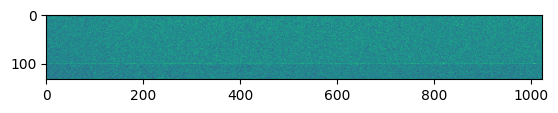

In [ ]:
#Espectro preliminar
from matplotlib.colors import LogNorm

fig9 = plt.figure()
plt.imshow(data.T, cmap='viridis',norm=LogNorm())
plt.grid(False)

In [ ]:
obj_name = h1.get('OBJECT', 'Unknown')
obj_name

'biases 1st afternoon'

In [ ]:
print(data.shape)
#Traspuesta de los datos para que el espectro salga a lo largo del eje x
#data= data.T

(1024, 133)


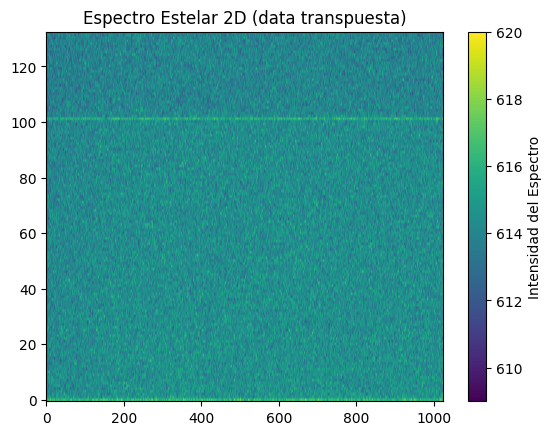

In [ ]:
plt.imshow(data.T, cmap='viridis', origin='lower', aspect='auto')
plt.colorbar(label='Intensidad del Espectro')

plt.title('Espectro Estelar 2D (data transpuesta)')
plt.show()


In [ ]:
archivos = glob(espectro)
imagen = [fits.getdata(i) for i in archivos]

In [ ]:
!pip install specutils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 10.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 kB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.6/83.6 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 11.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.4/275.4 kB 18.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 kB 4.5 MB/s eta 0:00:00


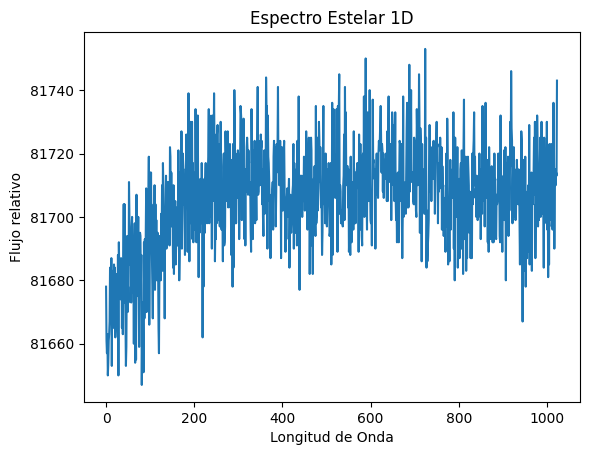

In [ ]:
#Convertir el espectro de 2d a 1d

spectrum_1d = np.sum(data.T, axis=0)

# Mostrar una gráfica del espectro 1D
plt.plot(spectrum_1d)
plt.xlabel('Longitud de Onda')
plt.ylabel('Flujo relativo')
plt.title('Espectro Estelar 1D')
plt.show()



**Normalización del espectro a partir de su continuo**

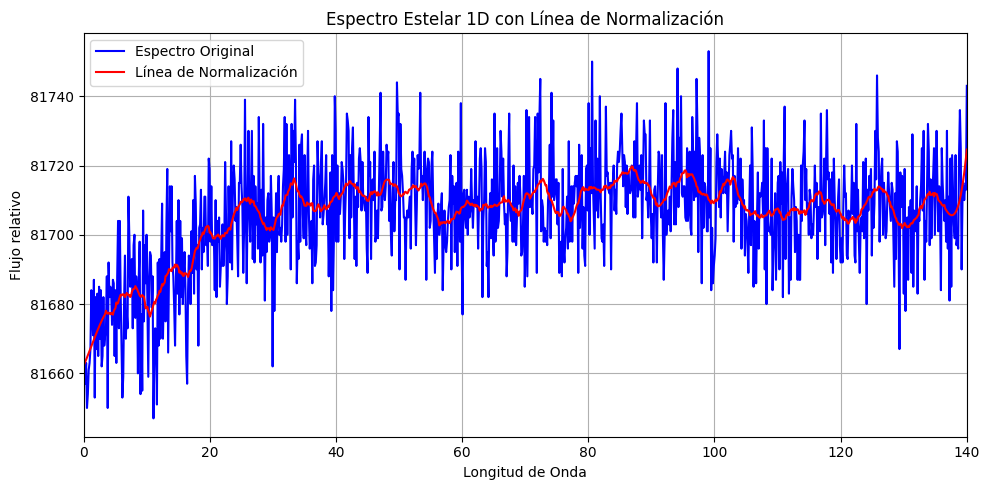

In [ ]:

from astropy.modeling import models, fitting
from scipy.signal import savgol_filter

longitudes_de_onda = np.linspace(0, 140, len(spectrum_1d))
continuo_fit = savgol_filter(spectrum_1d, 51, 3)

plt.figure(figsize=(10, 5))
plt.plot(longitudes_de_onda, spectrum_1d, label='Espectro Original', color='blue')
plt.plot(longitudes_de_onda, continuo_fit, label='Línea de Normalización', color='red')
plt.xlabel('Longitud de Onda')
plt.ylabel('Flujo relativo')
plt.title('Espectro Estelar 1D con Línea de Normalización')
plt.legend()
plt.grid(True)
plt.xlim(longitudes_de_onda[0], longitudes_de_onda[-1])  # Ajustar los límites de los ejes x
plt.tight_layout()  # Mejorar el diseño de la gráfica
plt.show()


In [ ]:
###################################################
####Duda: Cómo generar un espectro sintético#######
###################################################


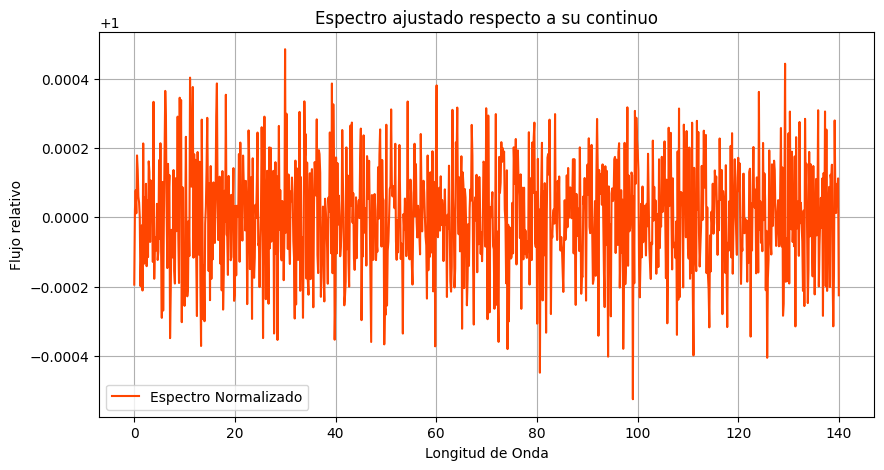

In [ ]:
# Gráfica del espectro dividido entre la línea de normalización (sirve para disminuir errores debidos al ruido)
# El ajuste se hace restando al espectro original el continuo

espectro_corregido= continuo_fit/spectrum_1d

plt.figure(figsize=(10, 5))
plt.plot(longitudes_de_onda, espectro_corregido, label='Espectro Normalizado', color='orangered')
plt.xlabel('Longitud de Onda')
plt.ylabel('Flujo relativo')
plt.title('Espectro ajustado respecto a su continuo')
plt.legend()
plt.grid(True)
plt.show()

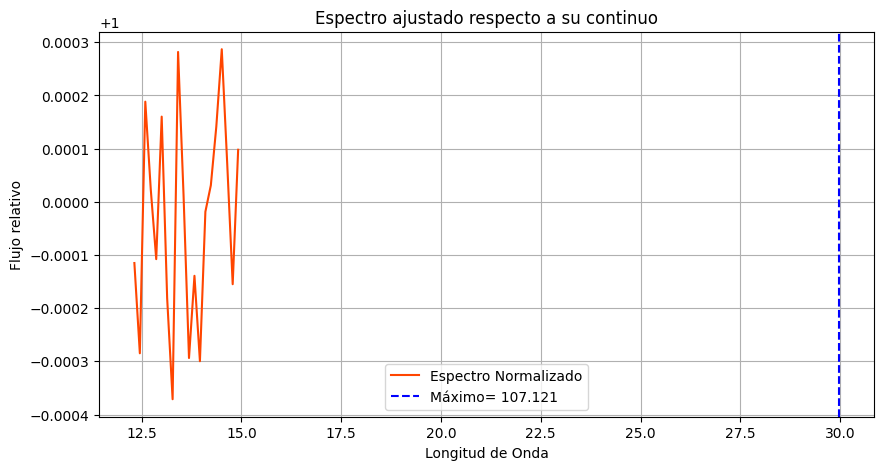

In [ ]:
#Cálculo del ancho de la linea espectral y zoom en la zona de la línea espectral
from scipy.optimize import curve_fit


maximo= np.max(espectro_corregido) #calcula el punto máximo de la lista de espectro, esto nos ubica en la línea espectral de interés
posicion_maximo = np.argmax(espectro_corregido)
maxim_location= longitudes_de_onda[posicion_maximo]


"""def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

popt, pcov = curve_fit(gaussian, longitudes_de_onda[90:110], espectro_corregido[90:110], p0=[np.max(espectro_corregido), 2, 1])
# Trazar una línea vertical en el punto del máximo absoluto
p0 = [np.max(espectro_corregido), maxim_location, 1]"""
plt.figure(figsize=(10, 5))
plt.plot(longitudes_de_onda[90:110], espectro_corregido[90:110], label='Espectro Normalizado', color='orangered')
plt.xlabel('Longitud de Onda')
plt.ylabel('Flujo relativo')
plt.title('Espectro ajustado respecto a su continuo')
plt.axvline(x=longitudes_de_onda[posicion_maximo], color='b', linestyle='--', label='Máximo= 107.121')
#plt.scatter(longitudes_de_onda[90:110], espectro_corregido[90:110], label='Datos con ruido')
#plt.plot(longitudes_de_onda[90:110], gaussian(longitudes_de_onda[90:110], *popt), color='blue', label='Ajuste gaussiano')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
len( espectro_corregido[90:110])

20

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Ancho de la línea espectral: 1.0


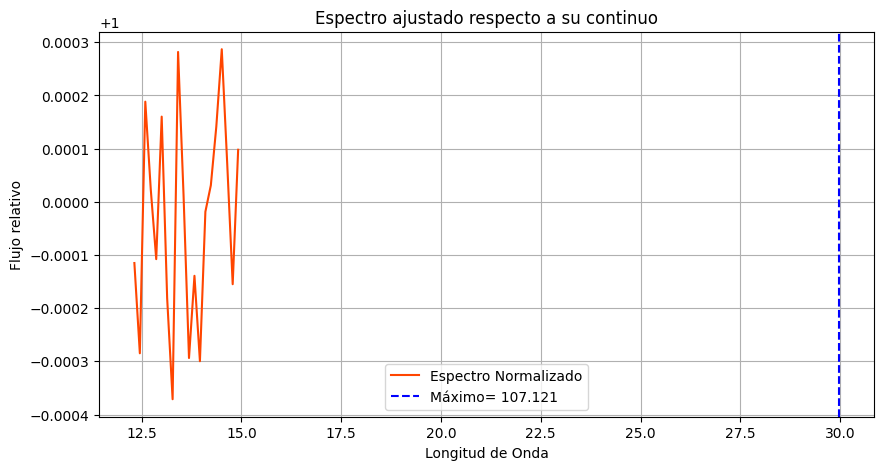

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Supongamos que ya tienes definidas las variables espectro_corregido y longitudes_de_onda

maximo = np.max(espectro_corregido)
posicion_maximo = np.argmax(espectro_corregido)
maxim_location = longitudes_de_onda[posicion_maximo]

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Ajuste gaussiano a la región cercana al pico
popt, pcov = curve_fit(gaussian, longitudes_de_onda[90:110], espectro_corregido[90:110], p0=[np.max(espectro_corregido), maxim_location, 1])

# Obtén el parámetro sigma del ajuste
ancho_linea_espectral = popt[2]

print("Ancho de la línea espectral:", ancho_linea_espectral)

plt.figure(figsize=(10, 5))
plt.plot(longitudes_de_onda[90:110], espectro_corregido[90:110], label='Espectro Normalizado', color='orangered')
plt.xlabel('Longitud de Onda')
plt.ylabel('Flujo relativo')
plt.title('Espectro ajustado respecto a su continuo')
plt.axvline(x=longitudes_de_onda[posicion_maximo], color='b', linestyle='--', label='Máximo= 107.121')
plt.legend()
plt.grid(True)
plt.show()
